In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 

### Bayesian  Analysis

In [2]:
from scipy import stats

In [6]:
df_clean=pd.read_csv(r"C:\Users\Pavitra\Downloads\AB_Testing_Project\notebooks\df_clean")

In [7]:
df_clean.head()

,user_id,timestamp,group,landing_page,converted
0,851104,2017-01-21 22:11:48.556739,control,old_page,0
1,804228,2017-01-12 08:01:45.159739,control,old_page,0
2,661590,2017-01-11 16:55:06.154213,treatment,new_page,0
3,853541,2017-01-08 18:28:03.143765,treatment,new_page,0
4,864975,2017-01-21 01:52:26.210827,control,old_page,1


In [8]:
control = df_clean[df_clean['group']=='control']
treatment = df_clean[df_clean['group']=='treatment']

In [11]:
len(treatment)

144389

In [9]:
prior_alpha, prior_beta = 1, 1    # "no prior belief"

control_successes = control['converted'].sum()
control_failures = len(control) - control_successes
treatment_successes = treatment['converted'].sum()
treatment_failures = len(treatment) - treatment_successes

# Posterior = prior + observed data (this is the conjugate update rule)

posterior_control = stats.beta(prior_alpha + control_successes, prior_beta + control_failures)
posterior_treatment = stats.beta(prior_alpha + treatment_successes, prior_beta + treatment_failures)

In [15]:
n_samples = 100_000
samples_control = posterior_control.rvs(n_samples)
samples_treatment = posterior_treatment.rvs(n_samples)

prob_treatment_better = (samples_treatment > samples_control).mean()
uplift_samples = samples_treatment - samples_control

print(f"P(Treatment > Control): {prob_treatment_better:.4f}")
print(f"Expected uplift: {uplift_samples.mean():.4f}")
print(f"95% Credible Interval: {np.percentile(uplift_samples, [2.5, 97.5])}") 
# This gives the range which has 95% probability of containing the true posterior uplift values.
prob_mde = (uplift_samples >= 0.02).mean()
print(f"P(Uplift >= 2pp): {prob_mde:.4f}")

P(Treatment > Control): 0.1111
Expected uplift: -0.0015
95% Credible Interval: [-0.00382343  0.00089685]
P(Uplift >= 2pp): 0.0000


Results :-
* P(Treatment > Control) = 0.1133
* Only 11.33% probability that treatment's true conversion rate is higher than control.
* Expected uplift = −0.0015
That's approximately −0.15 percentage points.So treatment is estimated to perform slightly worse than control.
* 95% Credible Interval = [−0.00383787, 0.00090821]
In percentage points: approximately [−0.384pp, +0.091pp].
This interval includes 0, so both a small negative effect and a small positive effect remain plausible.

Overall Bayesian conclusion :-

The Bayesian analysis provides little evidence that treatment improves conversion. There is only an 11.33% probability that treatment is better than control, and essentially no evidence of the desired +2pp improvement.

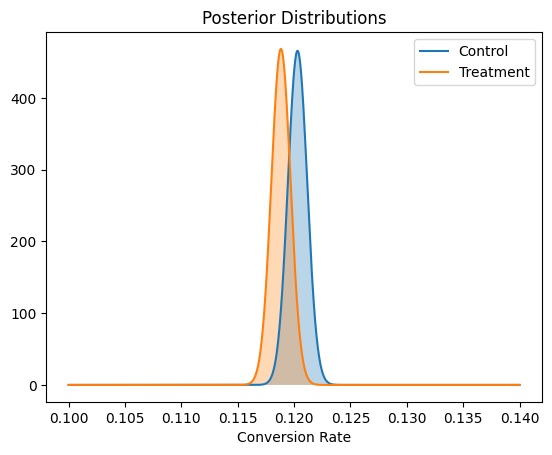

In [16]:
import matplotlib.pyplot as plt
x = np.linspace(0.10, 0.14, 1000)
plt.plot(x, posterior_control.pdf(x), label='Control')
plt.plot(x, posterior_treatment.pdf(x), label='Treatment')
plt.fill_between(x, posterior_control.pdf(x), alpha=0.3)
plt.fill_between(x, posterior_treatment.pdf(x), alpha=0.3)
plt.legend(); plt.xlabel('Conversion Rate'); plt.title('Posterior Distributions')
plt.savefig('../exports/bayesian_posteriors.png', dpi=150, bbox_inches='tight')
plt.show()